# <b><font color='teal'>Вопросы производительности. Работа со случайными числами</font></b>

### <font color='teal'>1. Скорость NumPy</font>

NumPy эффективно использует память для хранения массивов. <b>Операции выполняются на уровне C</b>, что минимизирует накладные расходы интерпретатора Python.
Благодаря тому, что элементы массива <b>хранятся в памяти последовательно и имеют фиксированный размер</b>, NumPy может точно вычислить, где в памяти находится каждый элемент. 

In [2]:
import numpy as np

N = 5000
list_2d = [[i + N*j for i in range(N)] for j in range(N)]
array_2d = np.array(list_2d)

In [10]:
import time
start = time.time()
# %%timeit 
#Умножение списков
list_2d_mult = [[list_2d[i][j] * list_2d[i][j] for j in range(N)] for i in range(N)]
end = time.time()
print("Время умножения списков:", end - start)

Время умножения списков: 3.204557418823242


In [12]:
%%timeit 
#Умножение списков
list_2d_mult = [[list_2d[i][j] * list_2d[i][j] for j in range(N)] for i in range(N)]


2.13 s ± 291 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [13]:
import timeit
timeit.timeit("list_2d_mult = [[list_2d[i][j] * list_2d[i][j] for j in range(N)] for i in range(N)]", globals=globals(), number=10)

25.267756000044756

In [6]:
start = time.time()
# %%timeit
#Умножение списков
arr = []
for i in range(N):
    subarr = []
    for j in range(N):
        subarr.append(list_2d[i][j] * list_2d[i][j])
    arr.append(subarr)
end = time.time()
print("Время умножения списков (второй способ):", end - start)

Время умножения списков (второй способ): 4.26302433013916


In [8]:
start = time.time()
# %%timeit
#Умножение матриц
array_2d_mult = array_2d * array_2d
end = time.time()
print("Время умножения матриц:", end - start)

Время умножения матриц: 0.08041930198669434


### <font color='teal'>2. Последовательное и строчное расположение</font>

В NumPy можно выбирать между "C-style" и "Fortran-style" порядками хранения данных, где "C-style" означает последовательное расположение по строкам, а "Fortran-style" - по по столбцам.

In [14]:
N = 1000  # размер матрицы

# Создаём одинаковые матрицы в разном порядке хранения
A_c = np.ones((N, N), order='C') #C-style
A_f = np.ones((N, N), order='F') #Fortran-style

In [15]:
%%timeit
#C-order
A_c.sum(axis=1)

441 μs ± 134 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [16]:
%%timeit
#C-order
A_c.sum(axis=0)

143 μs ± 9.37 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [17]:
%%timeit
#Fortran-order
A_f.sum(axis=1)

151 μs ± 10.7 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [18]:
%%timeit
#Fortran-order
A_f.sum(axis=0)

408 μs ± 105 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


### <font color='teal'>3. Работа с библиотекой numpy.random</font>

In [19]:
# случайное число или массив чисел в диапазоне
# randint(low[, high, size, dtype])
np.random.randint(5, 100, 10, int)

array([80, 53, 57, 16, 17, 86, 71, 86, 72, 13], dtype=int32)

In [25]:
# создание массив указанного размера со значениями от 0 до 1
# rand(size)
print(np.random.rand(10))

[0.83802008 0.45802631 0.53971999 0.56350848 0.274363   0.06345189
 0.44468538 0.19964455 0.83333312 0.92070754]


In [24]:
a = np.random.randint(5, 100, 10, int)
print(a)
# Генерирует случайную выборку из заданного одномерного массива;
print(np.random.choice(a, 5))

[72 74 82 18 91 27 99 47 76 82]
[91 27 27 99 99]


In [28]:
# Изменение массива, перемешивая его значения; Исходный массив меняется
np.random.shuffle(a)
print(a)

[74 99 76 72 91 82 47 18 27 82]


In [36]:
# Перемешивание значений массива и возвращаение его перемешанной копию, исходный массив не изменяется
a = np.random.randint(5, 100, 10, int)
print(a)
b = np.random.permutation(a)
# print(a)
print(b)

[44 47 41 17 73 55 94 81 43 85]
[73 44 47 94 41 55 81 17 43 85]


### <font color='teal'>3. Распределения</font>

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

[ 7.50695950e+00  6.98295382e+00  5.79404538e+00  7.96740989e+00
  8.63815794e+00  8.07473641e+00  6.71261340e+00  7.48428286e+00
  1.99812556e+00  3.50851772e+00  1.41612392e+00 -5.40043439e-01
  1.06070270e+01  2.23986195e+00  5.00522255e+00  6.93817806e+00
  2.63766570e+00  9.78190344e+00  1.05209983e+01  2.81830630e+00
  6.07916045e+00  6.71508093e+00  4.31556247e+00  9.94061972e+00
  9.73598712e+00  9.68473092e+00  7.38110716e+00  9.84523127e+00
  1.06684222e+01 -1.38180893e+00  6.91022794e+00  1.02664771e+01
  3.76369267e+00  8.50757163e+00  4.43061952e+00 -5.62747480e-01
 -9.66532792e-01  4.08723906e+00  1.78559139e+00  2.66713121e+00
  2.65669575e+00  2.39717055e+00  5.74897108e+00  1.04167447e+01
  6.95822909e+00  5.89391660e+00  9.31151648e+00  2.90222837e+00
  5.19553890e+00  7.18903141e+00  1.14424745e+01  2.17172426e+00
  3.97967154e+00  4.69774309e+00  6.43493285e+00  9.43128187e-01
  3.19686649e+00  5.00300172e+00  6.37113015e+00  5.66585323e+00
  4.01403751e+00  3.93271

C:\Users\Vitaliy\AppData\Local\Temp\ipykernel_41536\4248886357.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(value)


<Axes: ylabel='Density'>

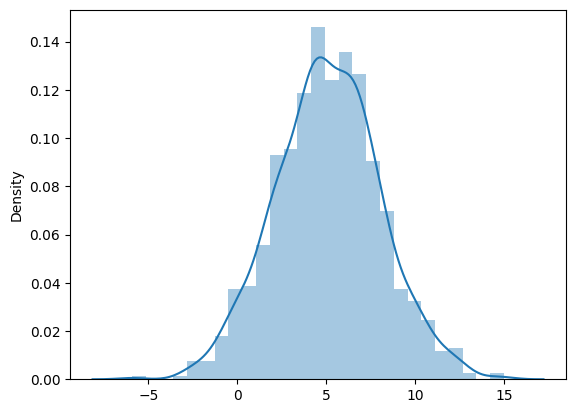

In [4]:
# Нормальное распределение  
#x_axis = np.random.normal(size=100)
value = np.random.normal(loc=5,scale=3,size=1000)
print(value)
sns.distplot(value)

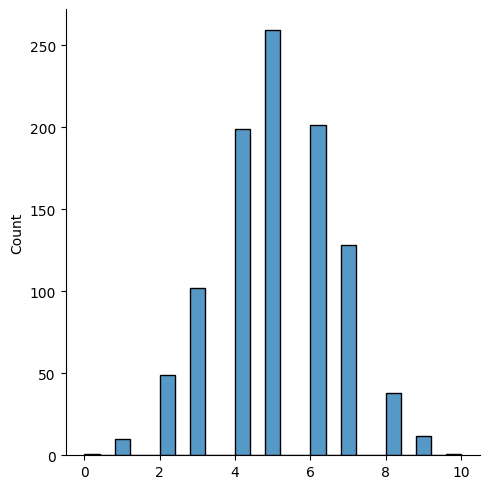

In [5]:
#Биномиальное распределение
sns.displot(np.random.binomial(n=10, p=0.5, size=1000))

### <font color='teal'>4. Решение задач</font>

1.  Генерация случайных данных и статистический анализ:<br>
    Напишите программу, которая:
- Запрашивает у пользователя количество точек данных N.
- Генерирует массив из N случайных точек (координаты x и y), используя нормальное распределение. Здесь можно использовать функцию zip(x, y)
- Выводит на экран первые 10 сгенерированных точек (если N было больше 10).
- Вычисляет и выводит среднее значение и стандартное отклонение для координат x и y.

Пример вывода:

Введите количество точек данных: 1000 <br>
Первые 10 точек: [(0.1, -0.2), (-1.3, 1.4), ...] <br>

Среднее значение по x: 0.02 <br>
Стандартное отклонение по x: 1.0 <br>
Среднее значение по y: -0.03 <br>
Стандартное отклонение по y: 1.01


In [ ]:
N = int(input("Введите количество точек данных: "))
x = np.random.normal(loc=5, scale=3, size=N)
y = np.random.normal(loc=5, scale=3, size=N)
zipped = list(zip(x, y))

if N > 10:
    print("Первые 10 точек:", [tuple(map(float, zipped[i])) for i in range(10)])
else:
    print("Все точки:", [tuple(map(float, point)) for point in zipped])
print("---------------------------------------")
print("Среднее значение по x:", round(np.mean(x), 2))
print("Стандартное отклонение по x:", round(np.std(x), 2))
print("Среднее значение по y:", round(np.mean(y), 2))
print("Стандартное отклонение по y:", round(np.std(y), 2))
print("---------------------------------------")


[(np.float64(1.1953884758437288), np.float64(0.3201037579111974)), (np.float64(4.730861823297096), np.float64(6.543568584331314)), (np.float64(4.642483327789082), np.float64(9.574117736497756)), (np.float64(0.43957138030803655), np.float64(1.942802385607453)), (np.float64(4.004782943443797), np.float64(8.154723544386593)), (np.float64(5.644261245908856), np.float64(6.645681235995188)), (np.float64(5.288748351892125), np.float64(5.819861285734158)), (np.float64(3.3854698409165067), np.float64(5.145640410048039)), (np.float64(5.828066051081034), np.float64(3.9879138105348577)), (np.float64(4.620805187853229), np.float64(5.823770150807159)), (np.float64(8.56292708687905), np.float64(8.165889110207615)), (np.float64(3.724628460454679), np.float64(-0.2856588702080476)), (np.float64(5.022921911387182), np.float64(5.234464708006349)), (np.float64(16.257592421748203), np.float64(3.7428997698824924)), (np.float64(6.833066622641438), np.float64(0.15203449889171416)), (np.float64(3.63664182091986